# 01 — Análisis Exploratorio de Datos (EDA)
**Sistema de Predicción de Enfermedades Cardiovasculares**
Sebastián Torres · Mayerlis Acosta Peralta · Christian Rivera

---
Este notebook carga el dataset `cardio_train.csv`, inspecciona su estructura, analiza la distribución de cada variable, detecta outliers y documenta en detalle los sesgos de `smoke` y `alco`. Los hallazgos aquí guían todas las decisiones de limpieza en `02_preprocessing.ipynb`.

## 1. Configuración del entorno
Montamos Google Drive y configuramos las rutas. El dataset vive en `cardio-backend/data/raw/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = '/content/drive/MyDrive/cardio-backend/data/raw/cardio_train.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✓ Entorno listo')

Mounted at /content/drive
✓ Entorno listo


## 2. Carga del dataset
El separador del CSV es punto y coma (`;`). Verificamos que las 13 columnas y los 70 000 registros carguen correctamente.

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Registros: {len(df):,}   |   Columnas: {df.shape[1]}')
df.head()

Registros: 70,000   |   Columnas: 13


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

=== Tipos de datos ===
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

=== Valores nulos por columna ===
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


## 3. Descripción de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | int | Identificador — se descarta antes de entrenar |
| `age` | int (días) | Edad en días → se convierte a años en preprocesamiento |
| `gender` | categórica | 1 = mujer · 2 = hombre |
| `height` | int (cm) | Altura |
| `weight` | float (kg) | Peso |
| `ap_hi` | int | Presión sistólica |
| `ap_lo` | int | Presión diastólica |
| `cholesterol` | ordinal | 1 normal · 2 alto · 3 muy alto |
| `gluc` | ordinal | 1 normal · 2 alto · 3 muy alto |
| `smoke` | binaria | 0 no fuma · 1 fuma |
| `alco` | binaria | 0 no consume · 1 consume alcohol |
| `active` | binaria | 0 no activo · 1 activo físicamente |
| `cardio` | **objetivo** | 0 sin enfermedad · 1 con enfermedad |

## 4. Estadísticas descriptivas
Resumen numérico de todas las variables. Presta atención a los valores mínimos y máximos de `ap_hi` y `ap_lo` — ya anticipan outliers extremos.

In [4]:
df.describe().round(2)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


## 5. Variable objetivo — `cardio`
Verificamos el balance de clases. Un dataset balanceado simplifica el entrenamiento porque no necesita técnicas de sobremuestreo como SMOTE.

=== Distribución de cardio ===
  Sin enfermedad (0): 35,021  (50.0%)
  Con enfermedad (1): 34,979  (50.0%)


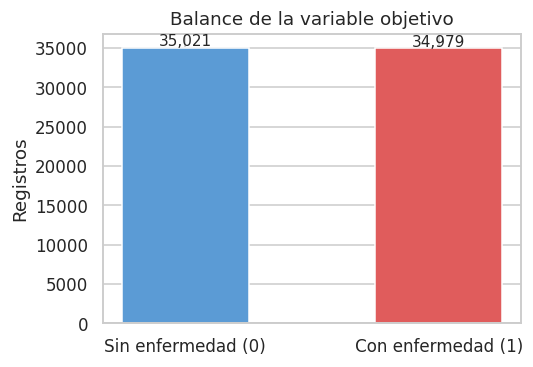

In [5]:
conteo = df['cardio'].value_counts()
porcentaje = df['cardio'].value_counts(normalize=True) * 100

print('=== Distribución de cardio ===')
print(f'  Sin enfermedad (0): {conteo[0]:,}  ({porcentaje[0]:.1f}%)')
print(f'  Con enfermedad (1): {conteo[1]:,}  ({porcentaje[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Sin enfermedad (0)', 'Con enfermedad (1)'], conteo.values,
       color=['#5b9bd5', '#e05c5c'], edgecolor='white', width=0.5)
ax.set_ylabel('Registros')
ax.set_title('Balance de la variable objetivo')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Distribución de variables numéricas
Histogramas de edad, altura, peso y presión arterial. Las colas largas en `ap_hi` y `ap_lo` confirman la presencia de outliers que se tratarán en el siguiente notebook.

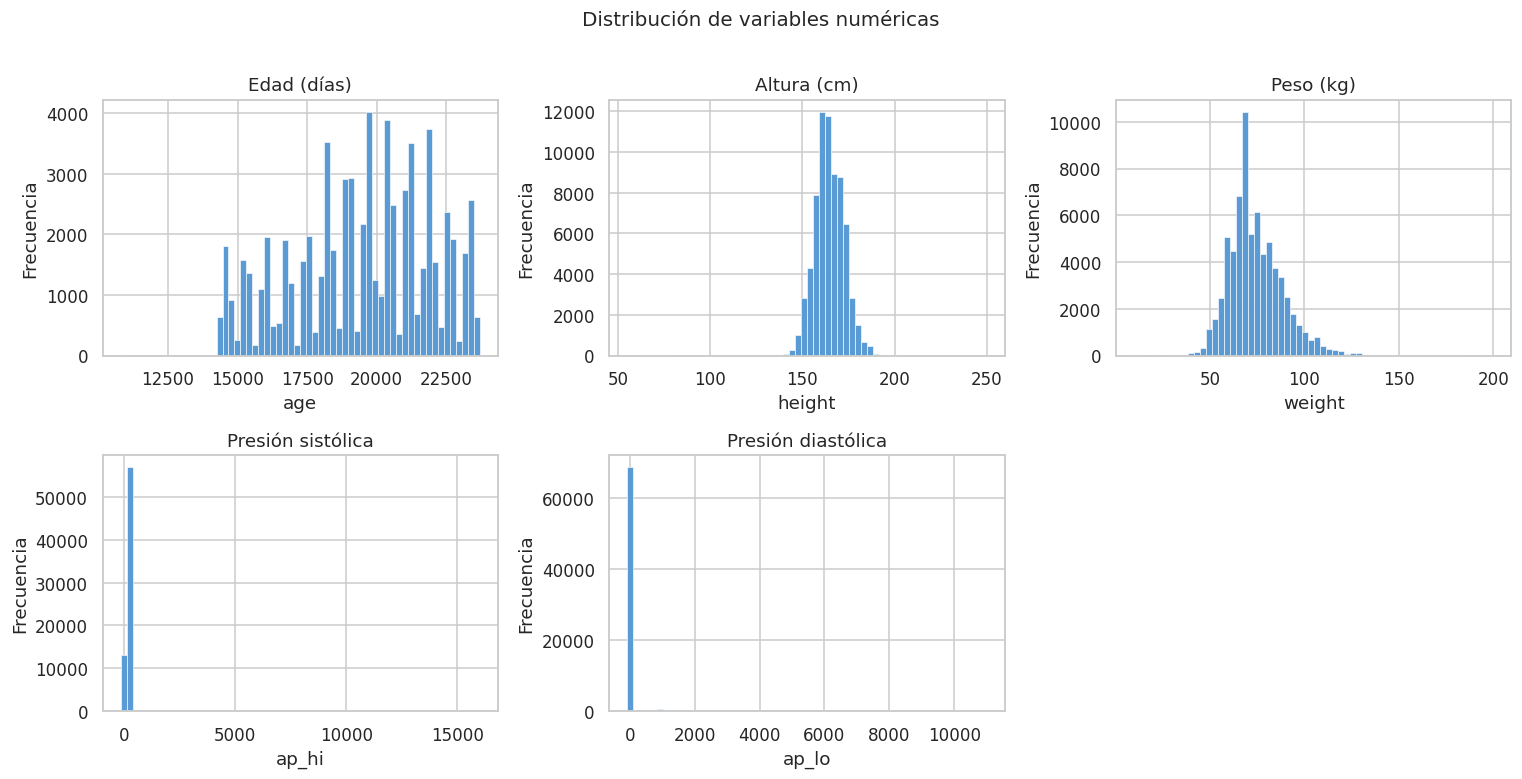

In [6]:
cols_num = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
labels   = ['Edad (días)', 'Altura (cm)', 'Peso (kg)', 'Presión sistólica', 'Presión diastólica']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cols_num, labels)):
    axes[i].hist(df[col], bins=60, color='#5b9bd5', edgecolor='white', linewidth=0.4)
    axes[i].set_title(label)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[5].set_visible(False)
plt.suptitle('Distribución de variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Outliers en presión arterial ⚠️
La presión arterial tiene errores de captura evidentes: valores negativos y valores fisiológicamente imposibles (ap_hi hasta 16 020 mmHg). Se documentan aquí para decidir el criterio de filtrado en preprocesamiento.

Rangos fisiológicos de referencia aceptados:
- `ap_hi`: 60 – 250 mmHg
- `ap_lo`: 40 – 200 mmHg

In [7]:
print('=== ap_hi ===')
print(f'  Mínimo: {df["ap_hi"].min()}   Máximo: {df["ap_hi"].max()}')
print(f'  Valores negativos:   {(df["ap_hi"] < 0).sum()}')
print(f'  Valores > 250 mmHg:  {(df["ap_hi"] > 250).sum()}')

print()
print('=== ap_lo ===')
print(f'  Mínimo: {df["ap_lo"].min()}   Máximo: {df["ap_lo"].max()}')
print(f'  Valores negativos:   {(df["ap_lo"] < 0).sum()}')
print(f'  Valores > 200 mmHg:  {(df["ap_lo"] > 200).sum()}')

print()
print('=== Casos donde ap_lo >= ap_hi (imposible fisiológicamente) ===')
print(f'  Registros: {(df["ap_lo"] >= df["ap_hi"]).sum():,}')

=== ap_hi ===
  Mínimo: -150   Máximo: 16020
  Valores negativos:   7
  Valores > 250 mmHg:  40

=== ap_lo ===
  Mínimo: -70   Máximo: 11000
  Valores negativos:   1
  Valores > 200 mmHg:  953

=== Casos donde ap_lo >= ap_hi (imposible fisiológicamente) ===
  Registros: 1,236


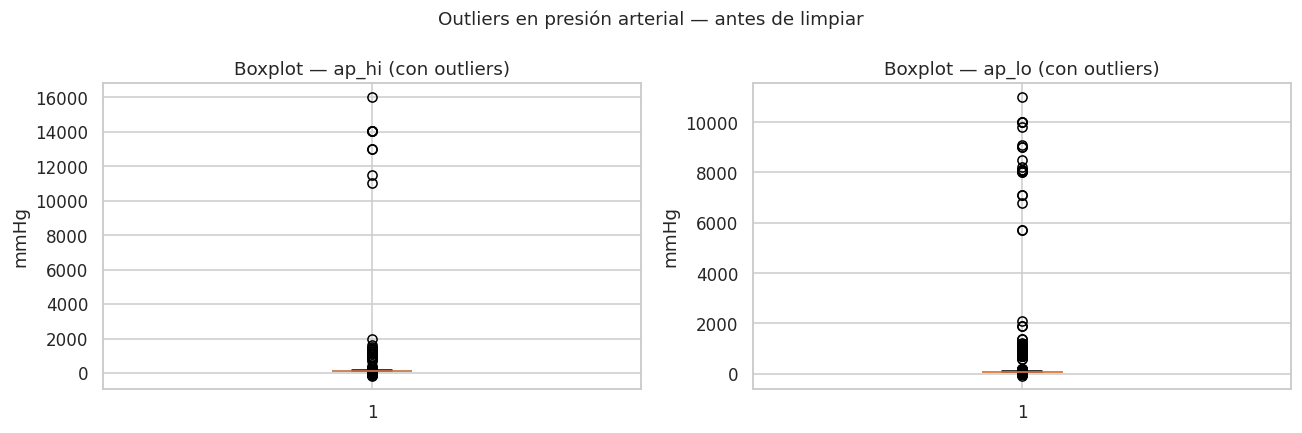

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['ap_hi'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#5b9bd5', color='#2d6da3'))
axes[0].set_title('Boxplot — ap_hi (con outliers)')
axes[0].set_ylabel('mmHg')

axes[1].boxplot(df['ap_lo'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#e89b5b', color='#b06b2e'))
axes[1].set_title('Boxplot — ap_lo (con outliers)')
axes[1].set_ylabel('mmHg')

plt.suptitle('Outliers en presión arterial — antes de limpiar', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Outliers en altura y peso
Altura mínima de 55 cm y peso mínimo de 10 kg son inverosímiles para adultos. Se revisan los extremos para definir el filtro en preprocesamiento.

In [9]:
print('=== Altura (cm) ===')
print(f'  Mínimo: {df["height"].min()}   Máximo: {df["height"].max()}')
print(f'  Registros con altura < 100 cm: {(df["height"] < 100).sum()}')
print(f'  Registros con altura > 220 cm: {(df["height"] > 220).sum()}')

print()
print('=== Peso (kg) ===')
print(f'  Mínimo: {df["weight"].min()}   Máximo: {df["weight"].max()}')
print(f'  Registros con peso < 30 kg: {(df["weight"] < 30).sum()}')
print(f'  Registros con peso > 180 kg: {(df["weight"] > 180).sum()}')

=== Altura (cm) ===
  Mínimo: 55   Máximo: 250
  Registros con altura < 100 cm: 29
  Registros con altura > 220 cm: 1

=== Peso (kg) ===
  Mínimo: 10.0   Máximo: 200.0
  Registros con peso < 30 kg: 7
  Registros con peso > 180 kg: 4


## 9. Distribución de variables categóricas
Frecuencias de género, colesterol, glucosa y los tres hábitos de vida. Se anticipa ya la baja representación de `smoke` y `alco` — ambas se analizan en detalle en las secciones siguientes.

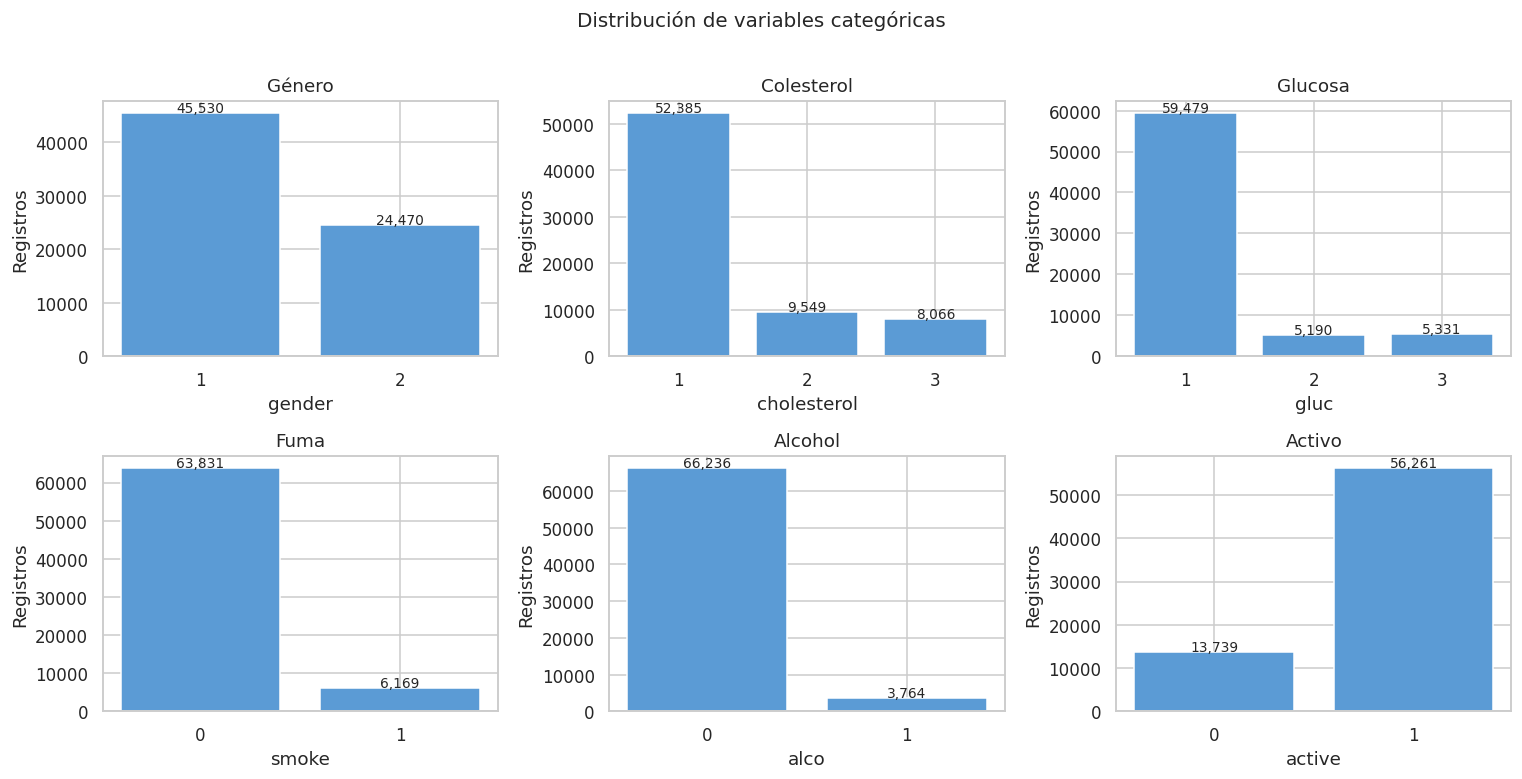

In [10]:
cat_cols   = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
cat_labels = ['Género', 'Colesterol', 'Glucosa', 'Fuma', 'Alcohol', 'Activo']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values, color='#5b9bd5', edgecolor='white')
    axes[i].set_title(label)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Registros')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Distribución de variables categóricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Sesgo en la variable `smoke` ⚠️

**El problema:**
Solo el 8.8% del dataset son fumadores (6 169 de 70 000 registros). De ese grupo, el 47.5% tiene enfermedad cardiovascular — paradójicamente **menos** que los no fumadores (50.2%). Esto contradice la evidencia médica: fumar es un factor de riesgo cardiovascular mayor reconocido globalmente.

**¿Por qué ocurre esto?**

1. **Subregistro autoreportado.** El dato lo declara el propio paciente. En contextos médicos las personas tienden a ocultar hábitos negativos, lo que produce una muestra de "fumadores declarados" que no representa la realidad poblacional.
2. **Sesgo de género diferencial.** El 21.9% de los hombres declara fumar frente al 1.8% de las mujeres. Una brecha tan extrema sugiere que el subregistro no es uniforme — es mucho más fuerte en mujeres, distorsionando aún más la señal.
3. **Perfil compensado.** Los fumadores que sí se declaran pueden tener otros factores protectores en la muestra (menor edad, más actividad física) que diluyen la señal del tabaquismo.

**Consecuencia para el modelo:**
El modelo aprenderá que `smoke=1` no aumenta el riesgo, lo cual es médicamente incorrecto. La variable tiene baja calidad de señal en este dataset.

**Lo que haremos:**
Conservar la variable — eliminarla perdería la poca señal que aporta. Pero en la salida de explicabilidad al médico se advertirá explícitamente que `smoke` puede estar subregistrada y que su impacto en el modelo no refleja el riesgo real del tabaquismo.

In [11]:
print('=== Distribución de smoke ===')
print(df['smoke'].value_counts())
print(f'\nPorcentaje de fumadores: {df["smoke"].mean()*100:.1f}%')

print()
print('=== Tasa de cardio=1 según smoke ===')
print(f'  Fumadores:     {df[df["smoke"]==1]["cardio"].mean()*100:.1f}% con enfermedad')
print(f'  No fumadores:  {df[df["smoke"]==0]["cardio"].mean()*100:.1f}% con enfermedad')

print()
print('=== Fumadores por género (proporción) ===')
print(pd.crosstab(df['gender'], df['smoke'], normalize='index').round(3))
print('(género 1 = mujer, 2 = hombre)')

print()
print('=== Correlación smoke con cardio ===')
print(round(df['smoke'].corr(df['cardio']), 4))

=== Distribución de smoke ===
smoke
0    63831
1     6169
Name: count, dtype: int64

Porcentaje de fumadores: 8.8%

=== Tasa de cardio=1 según smoke ===
  Fumadores:     47.5% con enfermedad
  No fumadores:  50.2% con enfermedad

=== Fumadores por género (proporción) ===
smoke       0      1
gender              
1       0.982  0.018
2       0.781  0.219
(género 1 = mujer, 2 = hombre)

=== Correlación smoke con cardio ===
-0.0155


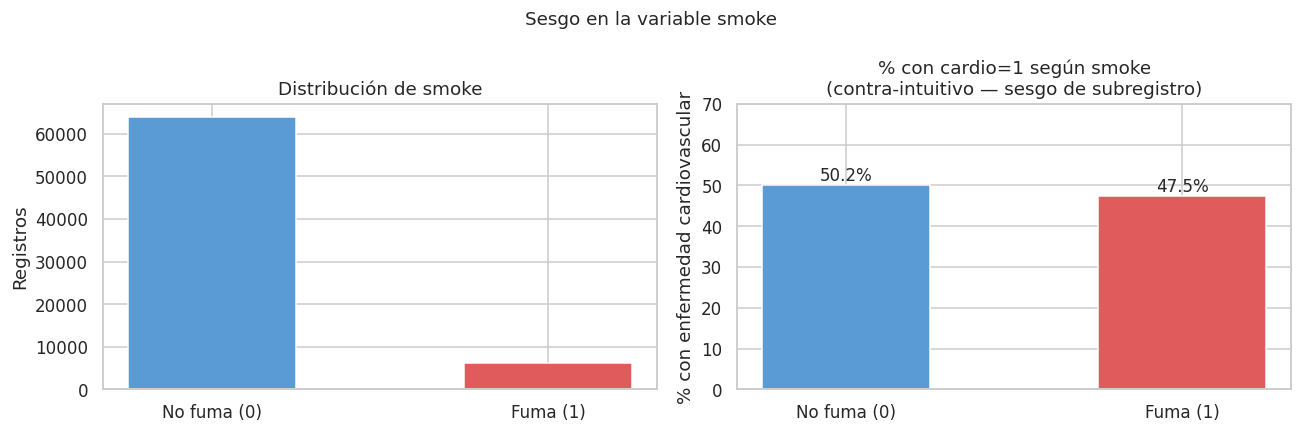

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: proporción de fumadores
axes[0].bar(['No fuma (0)', 'Fuma (1)'],
            df['smoke'].value_counts().sort_index().values,
            color=['#5b9bd5', '#e05c5c'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de smoke')
axes[0].set_ylabel('Registros')

# Derecha: tasa cardio=1 por grupo
tasas = df.groupby('smoke')['cardio'].mean() * 100
axes[1].bar(['No fuma (0)', 'Fuma (1)'], tasas.values,
            color=['#5b9bd5', '#e05c5c'], edgecolor='white', width=0.5)
axes[1].set_ylim(0, 70)
axes[1].set_title('% con cardio=1 según smoke\n(contra-intuitivo — sesgo de subregistro)')
axes[1].set_ylabel('% con enfermedad cardiovascular')
for i, v in enumerate(tasas.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Sesgo en la variable smoke', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Sesgo en la variable `alco` ⚠️

**El problema:**
Solo el 5.4% del dataset declara consumir alcohol (3 764 de 70 000). Los consumidores muestran una tasa de cardio de 48.4% frente al 50.1% de los no consumidores — correlación de **-0.007**, prácticamente cero y ligeramente negativa. Médicamente el consumo excesivo de alcohol es un factor de riesgo cardiovascular establecido, por lo que esta relación inversa no tiene sentido clínico.

**¿Por qué ocurre esto?**

1. **Subregistro aún más severo que `smoke`.** Con solo el 5.4% de positivos, la muestra de consumidores es demasiado pequeña y sesgada para representar la realidad. El mismo mecanismo de ocultamiento en contexto médico aplica, y es más intenso porque el estigma social del alcohol puede ser mayor.
2. **Sesgo de género diferencial.** El 10.6% de los hombres declara consumir alcohol frente al 2.5% de las mujeres — la misma brecha desproporcionada que en `smoke`, lo que confirma un patrón sistemático de subregistro diferencial por género en los hábitos de vida.
3. **Efecto combinado con smoke.** Cuando se analizan los pacientes con `smoke=1` y `alco=1` simultáneamente, la tasa de cardio baja al 44.4% — el valor más bajo de toda la tabla. Esto es el punto más absurdo del dataset y confirma que ambas variables comparten el mismo problema: los que declaran ambos hábitos son un grupo tan pequeño y atípico que genera ruido en lugar de señal.

**Diferencia clave con `smoke`:**
`alco` tiene incluso menos señal que `smoke`. La correlación de `smoke` con `cardio` es -0.0088 y la de `alco` es -0.0073 — ambas cercanas a cero, pero `alco` con una muestra aún más reducida. En la práctica, el modelo difícilmente podrá aprender algo útil de esta variable.

**Lo que haremos:**
Igual que con `smoke`: conservar la variable pero advertir en la explicabilidad al médico que `alco` sufre de subregistro severo y que un valor de 0 no garantiza ausencia de consumo real.

In [14]:
print('=== Distribución de alco ===')
print(df['alco'].value_counts())
print(f'\nPorcentaje de consumidores de alcohol: {df["alco"].mean()*100:.1f}%')

print()
print('=== Tasa de cardio=1 según alco ===')
print(f'  Consume alcohol:  {df[df["alco"]==1]["cardio"].mean()*100:.1f}% con enfermedad')
print(f'  No consume:       {df[df["alco"]==0]["cardio"].mean()*100:.1f}% con enfermedad')

print()
print('=== Consumo de alcohol por género (proporción) ===')
print(pd.crosstab(df['gender'], df['alco'], normalize='index').round(3))
print('(género 1 = mujer, 2 = hombre)')

print()
print('=== Correlación alco con cardio ===')
print(round(df['alco'].corr(df['cardio']), 4))

print()
print('=== Efecto combinado smoke + alco sobre cardio ===')
print(df.groupby(['smoke', 'alco'])['cardio'].mean().round(3))

=== Distribución de alco ===
alco
0    66236
1     3764
Name: count, dtype: int64

Porcentaje de consumidores de alcohol: 5.4%

=== Tasa de cardio=1 según alco ===
  Consume alcohol:  48.4% con enfermedad
  No consume:       50.1% con enfermedad

=== Consumo de alcohol por género (proporción) ===
alco        0      1
gender              
1       0.975  0.025
2       0.894  0.106
(género 1 = mujer, 2 = hombre)

=== Correlación alco con cardio ===
-0.0073

=== Efecto combinado smoke + alco sobre cardio ===
smoke  alco
0      0       0.501
       1       0.523
1      0       0.488
       1       0.444
Name: cardio, dtype: float64


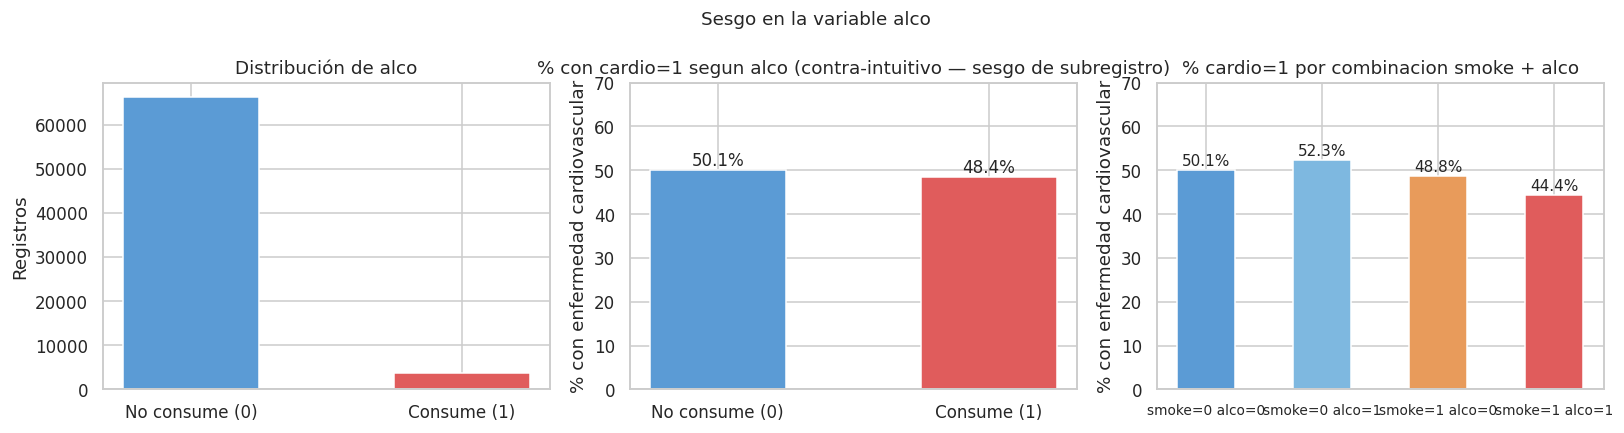

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución
axes[0].bar(['No consume (0)', 'Consume (1)'],
            df['alco'].value_counts().sort_index().values,
            color=['#5b9bd5', '#e05c5c'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de alco')
axes[0].set_ylabel('Registros')

# Tasa cardio por alco
tasas_alco = df.groupby('alco')['cardio'].mean() * 100
axes[1].bar(['No consume (0)', 'Consume (1)'], tasas_alco.values,
            color=['#5b9bd5', '#e05c5c'], edgecolor='white', width=0.5)
axes[1].set_ylim(0, 70)
axes[1].set_title('% con cardio=1 segun alco (contra-intuitivo — sesgo de subregistro)')
axes[1].set_ylabel('% con enfermedad cardiovascular')
for i, v in enumerate(tasas_alco.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

# Efecto combinado
combinado = df.groupby(['smoke', 'alco'])['cardio'].mean() * 100
etiquetas = [f'smoke={s} alco={a}' for s, a in combinado.index]
colores = ['#5b9bd5', '#7eb8e0', '#e89b5b', '#e05c5c']
axes[2].bar(range(len(combinado)), combinado.values, color=colores, edgecolor='white', width=0.5)
axes[2].set_xticks(range(len(combinado)))
axes[2].set_xticklabels(etiquetas, fontsize=9)
axes[2].set_ylim(0, 70)
axes[2].set_title('% cardio=1 por combinacion smoke + alco')
axes[2].set_ylabel('% con enfermedad cardiovascular')
for i, v in enumerate(combinado.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Sesgo en la variable alco', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Comparación directa: `smoke` vs `alco`
Tabla resumen que consolida los indicadores de sesgo de ambas variables. Sirve de referencia rápida para el equipo al momento de interpretar los resultados del modelo.

In [19]:
resumen = pd.DataFrame({
    'Variable': ['smoke', 'alco'],
    '% positivos en dataset': [
        round(df['smoke'].mean() * 100, 1),
        round(df['alco'].mean() * 100, 1)
    ],
    'Correlacion con cardio': [
        round(df['smoke'].corr(df['cardio']), 4),
        round(df['alco'].corr(df['cardio']), 4)
    ],
    '% cardio si positivo': [
        round(df[df['smoke']==1]['cardio'].mean() * 100, 1),
        round(df[df['alco']==1]['cardio'].mean() * 100, 1)
    ],
    '% cardio si negativo': [
        round(df[df['smoke']==0]['cardio'].mean() * 100, 1),
        round(df[df['alco']==0]['cardio'].mean() * 100, 1)
    ],
    '% hombres positivos': [
        round(df[df['gender']==2]['smoke'].mean() * 100, 1),
        round(df[df['gender']==2]['alco'].mean() * 100, 1)
    ],
    '% mujeres positivas': [
        round(df[df['gender']==1]['smoke'].mean() * 100, 1),
        round(df[df['gender']==1]['alco'].mean() * 100, 1)
    ],
})
resumen

,Variable,% positivos en dataset,Correlacion con cardio,% cardio si positivo,% cardio si negativo,% hombres positivos,% mujeres positivas
0,smoke,8.8,-0.0155,47.5,50.2,21.9,1.8
1,alco,5.4,-0.0073,48.4,50.1,10.6,2.5


## 13. Correlación de variables con `cardio`
Calculamos la correlación de Pearson de cada variable numérica con el objetivo. `ap_hi`, `ap_lo` y `cholesterol` muestran la asociación más fuerte — coherente con la evidencia médica.

=== Correlación con cardio ===
age            0.2382
cholesterol    0.2211
weight         0.1817
gluc           0.0893
ap_lo          0.0657
ap_hi          0.0545
gender         0.0081
alco          -0.0073
height        -0.0108
smoke         -0.0155
active        -0.0357
Name: cardio, dtype: float64


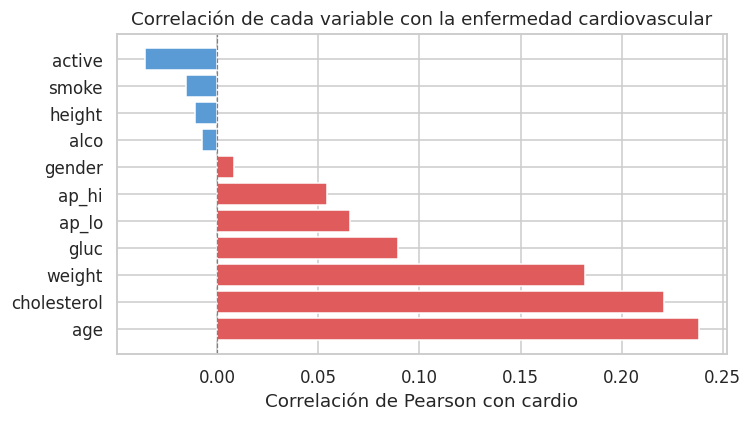

In [20]:
correlaciones = df.drop(columns=['id']).corr()['cardio'].drop('cardio').sort_values(ascending=False)

print('=== Correlación con cardio ===')
print(correlaciones.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#e05c5c' if v > 0 else '#5b9bd5' for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colores, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Correlación de Pearson con cardio')
ax.set_title('Correlación de cada variable con la enfermedad cardiovascular')
plt.tight_layout()
plt.show()

## 14. Mapa de correlaciones general
Vista completa de correlaciones entre todas las variables. Útil para detectar colinealidad que pueda afectar la interpretación del modelo.

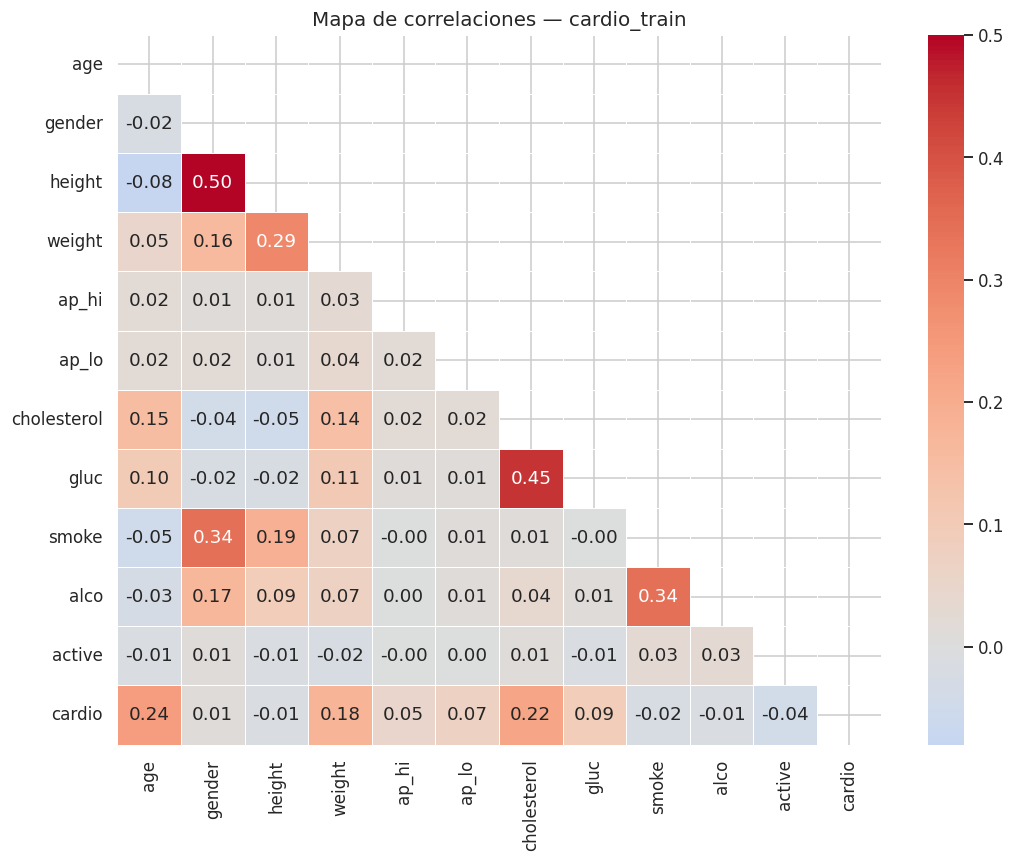

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(df.drop(columns=['id']).corr(), dtype=bool))
sns.heatmap(df.drop(columns=['id']).corr().round(2),
            mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax)
ax.set_title('Mapa de correlaciones — cardio_train', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Resumen de hallazgos y pendientes para preprocesamiento

### Hallazgos principales
- **Dataset balanceado:** 50.0% / 50.0% — no requiere técnicas de sobremuestreo.
- **Sin valores nulos** en ninguna columna.
- **Edad en días** (rango 10 798 – 23 713, equivale a 29 – 65 años) → convertir a años.
- **Outliers en `ap_hi`:** 7 valores negativos, 40 registros > 250 mmHg, máximo de 16 020.
- **Outliers en `ap_lo`:** 1 valor negativo, 953 registros > 200 mmHg, máximo de 11 000.
- **Casos imposibles:** registros donde `ap_lo >= ap_hi` — error de captura.
- **Outliers en `height`:** valores desde 55 cm — inverosímil para adultos.
- **Outliers en `weight`:** valores desde 10 kg — inverosímil para adultos.
- **Sesgo `smoke`:** 8.8% de positivos, correlación -0.0088, fumadores muestran menor tasa de cardio que no fumadores. Causa: subregistro autoreportado con sesgo de género diferencial. Ver sección 10.
- **Sesgo `alco`:** 5.4% de positivos, correlación -0.0073, consumidores muestran menor tasa de cardio. Mismo mecanismo que `smoke` pero con muestra aún más reducida. Ver sección 11.

### Acciones para `02_preprocessing.ipynb`
1. Eliminar columna `id`.
2. Convertir `age` de días a años.
3. Filtrar `ap_hi` al rango 60 – 250 mmHg.
4. Filtrar `ap_lo` al rango 40 – 200 mmHg.
5. Eliminar registros donde `ap_lo >= ap_hi`.
6. Filtrar `height` al rango 100 – 220 cm.
7. Filtrar `weight` al rango 30 – 180 kg.
8. Calcular IMC como feature derivado.
9. Guardar dataset limpio como `cardio_clean.csv`.
10. Documentar en `explainer.py` la advertencia sobre `smoke` y `alco` para el médico.